In [2]:
import sys
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = '/content/drive/MyDrive/liya_diploma'
    AI_TOOLKIT = '/content/ai-toolkit'
    get_ipython().system('pip install -q resvg-py datasets huggingface-hub Pillow tqdm')
except ModuleNotFoundError:
    _here = Path().resolve()
    DRIVE_ROOT = str(_here if (_here / 'scripts').exists() else _here.parent)
    AI_TOOLKIT = str(Path(DRIVE_ROOT).parent / 'ai-toolkit')

for p in (DRIVE_ROOT, AI_TOOLKIT):
    if p not in sys.path:
        sys.path.insert(0, p)

print(f"DRIVE_ROOT: {DRIVE_ROOT}")

SVG_DIR = f'{DRIVE_ROOT}/data/raw_svg'
PNG_DIR = f'{DRIVE_ROOT}/data/png_512'


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 13.0 MB/s eta 0:00:00
DRIVE_ROOT: /content/drive/MyDrive/liya_diploma


In [3]:
!cd /content/drive/MyDrive/liya_diploma && git pull

remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 69 (delta 30), reused 65 (delta 27), pack-reused 0 (from 0)
Unpacking objects: 100% (69/69), 17.29 MiB | 1.70 MiB/s, done.
From https://github.com/Superpevel/liya_diploma
   929dd2e..5013cde  main       -> origin/main
Updating 929dd2e..5013cde
Fast-forward
 .env.example                            |    11 +
 .gitignore                              |     3 +
 README.md                               |   140 +-
 README_BOT.md                           |    61 +
 bot/__init__.py                         |     0
 bot/config.py                           |   101 +
 bot/deps.py                             |    10 +
 bot/generator.py                        |   138 +
 bot/handlers.py                         |   227 +
 bot/main.py                             |    56 +
 bot/storage.py                          |   229 +
 bot/texts.py                      

In [6]:
from datasets import load_dataset

DATASETS = [
    ("iamkaikai/amazing_logos_v4",      "image", "text"),  # ~150k
    ("logo-wizard/modern-logo-dataset", "image", "text"),  # ~800
]
MAX_PER_DATASET = 5000  # ~5800 пар суммарно, можно поднять если есть время

datasets_list = []
for ds_id, img_field, cap_field in DATASETS:
    print(f"Loading {ds_id}...")
    ds = load_dataset(ds_id, split="train")
    if MAX_PER_DATASET and len(ds) > MAX_PER_DATASET:
        ds = ds.shuffle(seed=42).select(range(MAX_PER_DATASET))
    print(f"  kept {len(ds)} samples (image='{img_field}', caption='{cap_field}')")
    datasets_list.append((ds_id, ds, img_field, cap_field))

print(f"\nTotal: {sum(len(ds) for _, ds, _, _ in datasets_list)} samples")


Loading iamkaikai/amazing_logos_v4...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/408 [00:00<?, ?B/s]

data/train-00000-of-00014-8fa0be170a1cb1(…):   0%|          | 0.00/795M [00:00<?, ?B/s]

data/train-00001-of-00014-37a1302a48bbd8(…):   0%|          | 0.00/1.04G [00:00<?, ?B/s]

...

  kept 5000 samples (image='image', caption='text')
Loading logo-wizard/modern-logo-dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-b64601da56687a(…):   0%|          | 0.00/209M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/803 [00:00<?, ? examples/s]

  kept 803 samples (image='image', caption='text')

Total: 5803 samples


In [7]:
import json
from pathlib import Path

from PIL import Image
from tqdm import tqdm

Path(SVG_DIR).mkdir(parents=True, exist_ok=True)
Path(PNG_DIR).mkdir(parents=True, exist_ok=True)

prebuilt_captions = {}  # png_path -> caption, чтобы 02 пропускал готовое
idx = 0
n_svg = n_png = n_skip = 0

for ds_id, ds, img_field, cap_field in datasets_list:
    for item in tqdm(ds, desc=ds_id):
        if item.get("svg"):
            Path(f"{SVG_DIR}/{idx:06d}.svg").write_text(item["svg"], encoding="utf-8")
            n_svg += 1
            idx += 1
            continue

        img = item.get(img_field)
        if img is None:
            n_skip += 1
            continue

        img = img.convert("RGB")
        side = max(img.size)
        canvas = Image.new("RGB", (side, side), (255, 255, 255))
        canvas.paste(img, ((side - img.size[0]) // 2, (side - img.size[1]) // 2))
        png_path = f"{PNG_DIR}/{idx:06d}.png"
        canvas.resize((512, 512), Image.LANCZOS).save(png_path, "PNG")
        n_png += 1

        if cap_field and item.get(cap_field):
            prebuilt_captions[png_path] = item[cap_field]
        idx += 1

print(f"\nSaved {n_svg} SVG -> {SVG_DIR}")
print(f"Saved {n_png} PNG -> {PNG_DIR}")
if n_skip:
    print(f"Skipped {n_skip} items with missing image field")
print(f"Pre-built captions: {len(prebuilt_captions)}")

if prebuilt_captions:
    prebuilt_path = f"{DRIVE_ROOT}/data/prebuilt_captions.json"
    with open(prebuilt_path, "w", encoding="utf-8") as f:
        json.dump(prebuilt_captions, f, ensure_ascii=False, indent=2)
    print(f"Saved {prebuilt_path}")


logo-wizard/modern-logo-dataset: 100%|██████████| 803/803 [04:34<00:00,  2.93it/s]


Saved 0 SVG -> /content/drive/MyDrive/liya_diploma/data/raw_svg
Saved 5803 PNG -> /content/drive/MyDrive/liya_diploma/data/png_512
Pre-built captions: 5803


Saved /content/drive/MyDrive/liya_diploma/data/prebuilt_captions.json


In [8]:
from pathlib import Path

from scripts.svg_to_png import batch_convert

svg_files = list(Path(SVG_DIR).glob("**/*.svg"))
if svg_files:
    stats = batch_convert(SVG_DIR, PNG_DIR, size=512)
    print(f"Converted: {stats['success']} OK, {stats['failed']} failed of {stats['total']}")
else:
    n_pngs = len(list(Path(PNG_DIR).glob("*.png")))
    print(f"No SVG files in {SVG_DIR} - PNG-only dataset.")
    print(f"PNG_DIR has {n_pngs} images, skipping rasterisation.")


No SVG files in /content/drive/MyDrive/liya_diploma/data/raw_svg - PNG-only dataset.
PNG_DIR has 10000 images, skipping rasterisation.


In [9]:
import json
import importlib
import scripts.filter_dataset
importlib.reload(scripts.filter_dataset)
from scripts.filter_dataset import filter_dataset

filtered = filter_dataset(PNG_DIR, SVG_DIR, min_paths=3, max_paths=500)
print(f"After filtering: {len(filtered)} valid pairs")

with open(f'{DRIVE_ROOT}/data/filtered_pairs.jsonl', 'w') as f:
    for item in filtered:
        f.write(json.dumps(item) + '\n')
print("Saved data/filtered_pairs.jsonl")


After filtering: 10000 valid pairs
Saved data/filtered_pairs.jsonl


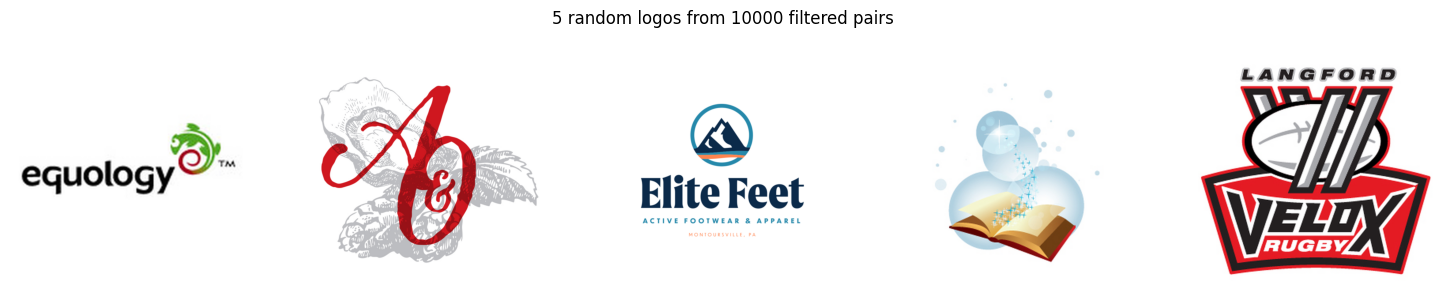

In [10]:
import os
import random

import matplotlib.pyplot as plt
from PIL import Image

if not filtered:
    print("Нечего показывать - filtered пустой. Смотри предыдущие ячейки.")
else:
    sample = random.sample(filtered, min(5, len(filtered)))
    fig, axes = plt.subplots(1, len(sample), figsize=(15, 3), squeeze=False)
    for ax, item in zip(axes[0], sample):
        ax.imshow(Image.open(item['png_path']))
        ax.axis('off')
    plt.suptitle(f"{len(sample)} random logos from {len(filtered)} filtered pairs")
    plt.tight_layout()

    out_path = f'{DRIVE_ROOT}/results/experiments/dataset_sample.png'
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, dpi=150)
    plt.show()
